In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/Country-data.csv
/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/data-dictionary.csv


In [2]:
import time
START = time.time()
 

In [3]:
import numpy as np
import pandas as pd
import warnings
import os
warnings.filterwarnings('ignore')

In [4]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.patches import Patch

In [5]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             silhouette_score, accuracy_score)
from sklearn.pipeline import Pipeline
 
# ── Input path (Kaggle) ───────────────────────────────────────────────────────
DATA_PATH = '/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/Country-data.csv'
if not os.path.exists(DATA_PATH):
    DATA_PATH = 'Country-data.csv'   # local fallback
 
PALETTE = {'Underdeveloped': '#E24B4A', 'Developing': '#F59E0B', 'Developed': '#378ADD'}
FEATURES = ['child_mort', 'exports', 'health', 'imports',
            'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']

In [6]:
print("=" * 65)
print("  CUSTOMER INTELLIGENCE SYSTEM — HELP INTERNATIONAL")
print("=" * 65)
 
df = pd.read_csv(DATA_PATH)
print(f"\n✅  Loaded {len(df)} countries × {df.shape[1]} features")
print(f"\n{'─'*40}")
print("DATASET OVERVIEW")
print(f"{'─'*40}")
print(df.describe().round(2).to_string())
 
print(f"\n{'─'*40}")
print("MISSING VALUES")
print(f"{'─'*40}")
print(df[FEATURES].isnull().sum())

  CUSTOMER INTELLIGENCE SYSTEM — HELP INTERNATIONAL

✅  Loaded 167 countries × 10 features

────────────────────────────────────────
DATASET OVERVIEW
────────────────────────────────────────
       child_mort  exports  health  imports     income  inflation  life_expec  total_fer       gdpp
count      167.00   167.00  167.00   167.00     167.00     167.00      167.00     167.00     167.00
mean        38.27    41.11    6.82    46.89   17144.69       7.78       70.56       2.95   12964.16
std         40.33    27.41    2.75    24.21   19278.07      10.57        8.89       1.51   18328.70
min          2.60     0.11    1.81     0.07     609.00      -4.21       32.10       1.15     231.00
25%          8.25    23.80    4.92    30.20    3355.00       1.81       65.30       1.80    1330.00
50%         19.30    35.00    6.32    43.30    9960.00       5.39       73.10       2.41    4660.00
75%         62.10    51.35    8.60    58.75   22800.00      10.75       76.80       3.88   14050.00
max      

In [7]:
X_raw = df[FEATURES].copy()
 
# StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
 
# PCA — 2 components for visualization
pca2 = PCA(n_components=2, random_state=42)
X_pca2 = pca2.fit_transform(X_scaled)
 
# PCA — keep 95% variance for modelling
pca95 = PCA(n_components=0.95, random_state=42)
X_pca95 = pca95.fit_transform(X_scaled)
 
print(f"\n{'─'*40}")
print("PCA SUMMARY")
print(f"{'─'*40}")
print(f"  PC1 explained variance : {pca2.explained_variance_ratio_[0]*100:.2f}%")
print(f"  PC2 explained variance : {pca2.explained_variance_ratio_[1]*100:.2f}%")
print(f"  2-component total      : {pca2.explained_variance_ratio_.sum()*100:.2f}%")
print(f"  Components for 95% var : {pca95.n_components_}")
 


────────────────────────────────────────
PCA SUMMARY
────────────────────────────────────────
  PC1 explained variance : 45.95%
  PC2 explained variance : 17.18%
  2-component total      : 63.13%
  Components for 95% var : 6


In [8]:
print(f"\n{'─'*40}")
print("K-MEANS CLUSTERING")
print(f"{'─'*40}")
 
inertia, sil_scores = [], []
K_RANGE = range(2, 9)
 
for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))
    print(f"  K={k} | Inertia={km.inertia_:8.1f} | Silhouette={sil_scores[-1]:.4f}")
 
best_k = K_RANGE[np.argmax(sil_scores)]
print(f"\n  ➜  Best K = {best_k}  (silhouette={max(sil_scores):.4f})")
 
# Final K-Means with K=3 (interpretable: Underdeveloped / Developing / Developed)
FINAL_K = 3
km_final = KMeans(n_clusters=FINAL_K, random_state=42, n_init=20)
km_labels = km_final.fit_predict(X_scaled)
df['cluster'] = km_labels
df['pc1']     = X_pca2[:, 0]
df['pc2']     = X_pca2[:, 1]


────────────────────────────────────────
K-MEANS CLUSTERING
────────────────────────────────────────
  K=2 | Inertia=  1050.2 | Silhouette=0.2874
  K=3 | Inertia=   831.4 | Silhouette=0.2833
  K=4 | Inertia=   700.5 | Silhouette=0.2960
  K=5 | Inertia=   620.2 | Silhouette=0.2993
  K=6 | Inertia=   558.5 | Silhouette=0.2287
  K=7 | Inertia=   495.8 | Silhouette=0.2477
  K=8 | Inertia=   457.6 | Silhouette=0.2388

  ➜  Best K = 5  (silhouette=0.2993)


In [9]:
gdpp_by_cluster = df.groupby('cluster')['gdpp'].mean().sort_values()
level_map = {}
level_names = ['Underdeveloped', 'Developing', 'Developed']
for i, (c, _) in enumerate(gdpp_by_cluster.items()):
    level_map[c] = level_names[i]
df['dev_level'] = df['cluster'].map(level_map)
 
print(f"\n  Cluster distribution:")
print(df['dev_level'].value_counts().to_string())
 
# Cluster profile
print(f"\n  Cluster profiles (mean):")
print(df.groupby('dev_level')[['child_mort','life_expec','income','gdpp','inflation','total_fer']]
        .mean().round(2).to_string())
 


  Cluster distribution:
dev_level
Developing        84
Underdeveloped    47
Developed         36

  Cluster profiles (mean):
                child_mort  life_expec    income      gdpp  inflation  total_fer
dev_level                                                                       
Developed             5.00       80.13  45672.22  42494.44       2.67       1.75
Developing           21.93       72.81  12305.60   6486.45       7.60       2.31
Underdeveloped       92.96       59.19   3942.40   1922.38      12.02       5.01


In [10]:
print(f"\n{'─'*40}")
print("DBSCAN CLUSTERING")
print(f"{'─'*40}")
 
dbscan = DBSCAN(eps=2.0, min_samples=5)
db_labels = dbscan.fit_predict(X_scaled)
n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise       = list(db_labels).count(-1)
df['dbscan_label'] = db_labels
 
print(f"  Core clusters found : {n_clusters_db}")
print(f"  Outlier / noise pts : {n_noise}")
print(f"  Outlier countries   : {list(df[df['dbscan_label']==-1]['country'])}")


────────────────────────────────────────
DBSCAN CLUSTERING
────────────────────────────────────────
  Core clusters found : 1
  Outlier / noise pts : 15
  Outlier countries   : ['Brunei', 'Equatorial Guinea', 'Haiti', 'Kuwait', 'Lesotho', 'Liberia', 'Luxembourg', 'Malta', 'Micronesia, Fed. Sts.', 'Mongolia', 'Nigeria', 'Qatar', 'Singapore', 'United States', 'Venezuela']


In [11]:
print(f"\n{'─'*40}")
print("ENSEMBLE CLASSIFICATION")
print(f"{'─'*40}")
 
le = LabelEncoder()
y  = le.fit_transform(df['dev_level'])          # 0=Developed 1=Developing 2=Underdeveloped
 
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42, stratify=y)
 
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
 
# ── Random Forest ─────────────────────────────────────────────────────────────
rf = RandomForestClassifier(n_estimators=200, max_depth=8,
                             min_samples_split=2, random_state=42, n_jobs=-1)
rf_cv   = cross_val_score(rf, X_scaled, y, cv=cv, scoring='accuracy')
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_acc  = accuracy_score(y_test, rf_pred)
 
print(f"\n  Random Forest")
print(f"    CV scores    : {np.round(rf_cv,4)}")
print(f"    CV mean±std  : {rf_cv.mean():.4f} ± {rf_cv.std():.4f}")
print(f"    Test accuracy: {rf_acc:.4f}  ({rf_acc*100:.1f}%)")
print(f"\n  Classification Report (RF):")
print(classification_report(y_test, rf_pred, target_names=le.classes_))


────────────────────────────────────────
ENSEMBLE CLASSIFICATION
────────────────────────────────────────

  Random Forest
    CV scores    : [0.9706 0.9706 1.     0.8788 1.    ]
    CV mean±std  : 0.9640 ± 0.0446
    Test accuracy: 0.9706  (97.1%)

  Classification Report (RF):
                precision    recall  f1-score   support

     Developed       1.00      1.00      1.00         7
    Developing       0.94      1.00      0.97        17
Underdeveloped       1.00      0.90      0.95        10

      accuracy                           0.97        34
     macro avg       0.98      0.97      0.97        34
  weighted avg       0.97      0.97      0.97        34



In [12]:
gbm = GradientBoostingClassifier(n_estimators=150, max_depth=4,
                                  learning_rate=0.1, subsample=0.8,
                                  random_state=42)
gbm_cv   = cross_val_score(gbm, X_scaled, y, cv=cv, scoring='accuracy')
gbm.fit(X_train, y_train)
gbm_pred = gbm.predict(X_test)
gbm_acc  = accuracy_score(y_test, gbm_pred)
 
print(f"\n  Gradient Boosting")
print(f"    CV scores    : {np.round(gbm_cv,4)}")
print(f"    CV mean±std  : {gbm_cv.mean():.4f} ± {gbm_cv.std():.4f}")
print(f"    Test accuracy: {gbm_acc:.4f}  ({gbm_acc*100:.1f}%)")
print(f"\n  Classification Report (GBM):")
print(classification_report(y_test, gbm_pred, target_names=le.classes_))


  Gradient Boosting
    CV scores    : [0.9412 0.9706 1.     0.8485 0.9697]
    CV mean±std  : 0.9460 ± 0.0522
    Test accuracy: 0.8529  (85.3%)

  Classification Report (GBM):
                precision    recall  f1-score   support

     Developed       0.86      0.86      0.86         7
    Developing       0.83      0.88      0.86        17
Underdeveloped       0.89      0.80      0.84        10

      accuracy                           0.85        34
     macro avg       0.86      0.85      0.85        34
  weighted avg       0.85      0.85      0.85        34



In [13]:
feat_df = pd.DataFrame({
    'Feature'   : FEATURES,
    'RF'        : rf.feature_importances_,
    'GBM'       : gbm.feature_importances_
}).sort_values('RF', ascending=False)
 
print(f"\n  Feature Importances:")
print(feat_df.round(4).to_string(index=False))


  Feature Importances:
   Feature     RF    GBM
child_mort 0.2836 0.4522
      gdpp 0.2303 0.4712
life_expec 0.1559 0.0129
 total_fer 0.1405 0.0570
    income 0.1352 0.0033
    health 0.0230 0.0016
 inflation 0.0141 0.0010
   exports 0.0088 0.0007
   imports 0.0085 0.0001


In [14]:
print(f"\n{'─'*40}")
print("AID PRIORITY — TOP 20 COUNTRIES")
print(f"{'─'*40}")
 
underdeveloped = df[df['dev_level'] == 'Underdeveloped'].copy()
underdeveloped['aid_score'] = (
    underdeveloped['child_mort'] / underdeveloped['child_mort'].max() * 0.4 +
    (1 - underdeveloped['life_expec'] / underdeveloped['life_expec'].max()) * 0.3 +
    (1 - underdeveloped['gdpp'] / underdeveloped['gdpp'].max()) * 0.3
)
top20 = underdeveloped.sort_values('aid_score', ascending=False).head(20)
print(top20[['country','child_mort','life_expec','gdpp','income','aid_score']]
      .round(3).to_string(index=False))


────────────────────────────────────────
AID PRIORITY — TOP 20 COUNTRIES
────────────────────────────────────────
                 country  child_mort  life_expec  gdpp  income  aid_score
                   Haiti       208.0        32.1   662    1500      0.853
Central African Republic       149.0        47.5   446     888      0.678
            Sierra Leone       160.0        55.0   399    1220      0.669
                    Chad       150.0        56.5   897    1930      0.634
                    Mali       137.0        59.5   708    1870      0.600
                   Niger       123.0        58.8   348     814      0.582
           Guinea-Bissau       114.0        55.6   547    1390      0.575
                 Lesotho        99.7        46.5  1170    2380      0.575
        Congo, Dem. Rep.       116.0        57.5   334     609      0.575
            Burkina Faso       116.0        57.9   575    1430      0.569
              Mozambique       101.0        54.5   419     918      0.5

In [15]:
print(f"\n{'─'*40}")
print("GENERATING VISUALIZATIONS ...")
print(f"{'─'*40}")
 
fig = plt.figure(figsize=(22, 26))
fig.patch.set_facecolor('#0F1117')
gs  = gridspec.GridSpec(4, 3, figure=fig, hspace=0.45, wspace=0.35)
 
txt_kw  = dict(color='white')
ax_kw   = dict(facecolor='#1A1D27')
grid_kw = dict(color='#2A2D3A', linewidth=0.5)
colors  = [PALETTE[l] for l in df['dev_level']]
 
# ── Helper ────────────────────────────────────────────────────────────────────
def style_ax(ax, title='', xlabel='', ylabel=''):
    ax.set_facecolor('#1A1D27')
    ax.tick_params(colors='#888888', labelsize=8)
    for sp in ax.spines.values(): sp.set_color('#2A2D3A')
    ax.grid(True, **grid_kw)
    if title:  ax.set_title(title,  color='white', fontsize=10, fontweight='bold', pad=6)
    if xlabel: ax.set_xlabel(xlabel, color='#888888', fontsize=8)
    if ylabel: ax.set_ylabel(ylabel, color='#888888', fontsize=8)


────────────────────────────────────────
GENERATING VISUALIZATIONS ...
────────────────────────────────────────


<Figure size 2200x2600 with 0 Axes>

In [16]:
ax1 = fig.add_subplot(gs[0, 0])
for lvl, col in PALETTE.items():
    mask = df['dev_level'] == lvl
    ax1.scatter(df.loc[mask,'pc1'], df.loc[mask,'pc2'],
                c=col, label=lvl, alpha=0.75, s=35, edgecolors='none')
style_ax(ax1, 'PCA Scatter — K-Means Clusters', 'PC1 (45.9%)', 'PC2 (17.2%)')
ax1.legend(fontsize=7, facecolor='#1A1D27', labelcolor='white', framealpha=0.6)
 

In [17]:
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(list(K_RANGE), inertia, 'o-', color='#F59E0B', linewidth=2, markersize=6)
ax2.axvline(x=FINAL_K, color='#E24B4A', linestyle='--', linewidth=1.5, label=f'K={FINAL_K}')
style_ax(ax2, 'Elbow Curve — Inertia vs K', 'Number of Clusters (K)', 'Inertia')
ax2.legend(fontsize=7, facecolor='#1A1D27', labelcolor='white')

In [18]:
ax3 = fig.add_subplot(gs[0, 2])
bar_cols = ['#378ADD' if k == best_k else '#2A4A7A' for k in K_RANGE]
ax3.bar(list(K_RANGE), sil_scores, color=bar_cols, edgecolor='none', zorder=3)
style_ax(ax3, 'Silhouette Score vs K', 'K', 'Silhouette Score')
ax3.set_xticks(list(K_RANGE))

In [19]:
ax4 = fig.add_subplot(gs[1, 0])
db_colors = {-1:'#888888', 0:'#378ADD'}
for lbl, col in db_colors.items():
    mask = df['dbscan_label'] == lbl
    label = 'Outlier' if lbl == -1 else 'Core cluster'
    ax4.scatter(df.loc[mask,'pc1'], df.loc[mask,'pc2'],
                c=col, alpha=0.7, s=30, label=label, edgecolors='none')
style_ax(ax4, 'DBSCAN Clustering (PCA Space)', 'PC1', 'PC2')
ax4.legend(fontsize=7, facecolor='#1A1D27', labelcolor='white')


In [20]:
ax5 = fig.add_subplot(gs[1, 1])
feat_sorted = feat_df.sort_values('RF')
ax5.barh(feat_sorted['Feature'], feat_sorted['RF'],
         color='#378ADD', edgecolor='none', zorder=3)
style_ax(ax5, 'Random Forest — Feature Importance', 'Importance', '')
ax5.tick_params(axis='y', labelsize=8, colors='#AAAAAA')

In [21]:
ax6 = fig.add_subplot(gs[1, 2])
feat_gbm = feat_df.sort_values('GBM')
ax6.barh(feat_gbm['Feature'], feat_gbm['GBM'],
         color='#F59E0B', edgecolor='none', zorder=3)
style_ax(ax6, 'Gradient Boosting — Feature Importance', 'Importance', '')
ax6.tick_params(axis='y', labelsize=8, colors='#AAAAAA')

In [22]:
ax7 = fig.add_subplot(gs[2, 0])
counts = df['dev_level'].value_counts()
wedge_props = dict(width=0.5, edgecolor='#0F1117', linewidth=2)
ax7.pie(counts.values,
        labels=counts.index,
        colors=[PALETTE[l] for l in counts.index],
        autopct='%1.1f%%',
        pctdistance=0.75,
        wedgeprops=wedge_props,
        textprops={'color':'white', 'fontsize':8})
ax7.set_facecolor('#1A1D27')
ax7.set_title('Country Distribution by Level', color='white', fontsize=10, fontweight='bold', pad=6)

Text(0.5, 1.0, 'Country Distribution by Level')

In [23]:
ax8 = fig.add_subplot(gs[2, 1])
folds = [f'Fold {i+1}' for i in range(5)]
ax8.bar(folds, rf_cv, color='#378ADD', alpha=0.85, edgecolor='none', zorder=3)
ax8.axhline(rf_cv.mean(), color='#E24B4A', linestyle='--', linewidth=1.5,
            label=f'Mean={rf_cv.mean():.3f}')
ax8.set_ylim(0.7, 1.05)
style_ax(ax8, 'Random Forest — CV Scores', 'Fold', 'Accuracy')
ax8.legend(fontsize=7, facecolor='#1A1D27', labelcolor='white')

In [24]:
ax9 = fig.add_subplot(gs[2, 2])
ax9.bar(folds, gbm_cv, color='#F59E0B', alpha=0.85, edgecolor='none', zorder=3)
ax9.axhline(gbm_cv.mean(), color='#E24B4A', linestyle='--', linewidth=1.5,
            label=f'Mean={gbm_cv.mean():.3f}')
ax9.set_ylim(0.7, 1.05)
style_ax(ax9, 'Gradient Boosting — CV Scores', 'Fold', 'Accuracy')
ax9.legend(fontsize=7, facecolor='#1A1D27', labelcolor='white')

In [25]:
ax10 = fig.add_subplot(gs[3, 0])
for lvl, col in PALETTE.items():
    mask = df['dev_level'] == lvl
    ax10.scatter(df.loc[mask,'gdpp'], df.loc[mask,'child_mort'],
                 c=col, alpha=0.75, s=35, label=lvl, edgecolors='none')
style_ax(ax10, 'GDP/cap vs Child Mortality', 'GDP per Capita ($)', 'Child Mortality /1000')
ax10.legend(fontsize=7, facecolor='#1A1D27', labelcolor='white')
 

In [26]:
ax11 = fig.add_subplot(gs[3, 1])
top10 = top20.head(10)
bars  = ax11.barh(top10['country'], top10['aid_score'],
                   color='#E24B4A', edgecolor='none', zorder=3)
style_ax(ax11, 'Top 10 Aid Priority Countries', 'Aid Priority Score', '')
ax11.invert_yaxis()
ax11.tick_params(axis='y', labelsize=7, colors='#AAAAAA')

In [27]:
ax12 = fig.add_subplot(gs[3, 2])
heat_data = df.groupby('dev_level')[['child_mort','life_expec','income',
                                      'gdpp','inflation','total_fer']].mean()
heat_norm  = (heat_data - heat_data.min()) / (heat_data.max() - heat_data.min())
im = ax12.imshow(heat_norm.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
ax12.set_xticks(range(len(heat_norm.columns)))
ax12.set_xticklabels(['Child\nmort','Life\nexp','Income','GDP/cap','Inflation','Fertility'],
                       fontsize=7, color='#AAAAAA')
ax12.set_yticks(range(len(heat_norm.index)))
ax12.set_yticklabels(heat_norm.index, fontsize=8, color='white')
ax12.set_title('Cluster Profile Heatmap (normalised)', color='white', fontsize=10,
               fontweight='bold', pad=6)
ax12.set_facecolor('#1A1D27')
for spine in ax12.spines.values(): spine.set_color('#2A2D3A')
for i in range(heat_norm.shape[0]):
    for j in range(heat_norm.shape[1]):
        ax12.text(j, i, f'{heat_norm.values[i,j]:.2f}',
                  ha='center', va='center', fontsize=7,
                  color='black' if 0.3 < heat_norm.values[i,j] < 0.7 else 'white')
 

In [28]:
fig.suptitle('Customer Intelligence System — HELP International\n'
             'Country Development Classification via K-Means | DBSCAN | Random Forest | Gradient Boosting',
             color='white', fontsize=14, fontweight='bold', y=0.995)
 
plt.savefig('customer_intelligence_system.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print("  ✅  Figure saved: customer_intelligence_system.png")
 

<Figure size 640x480 with 0 Axes>

  ✅  Figure saved: customer_intelligence_system.png


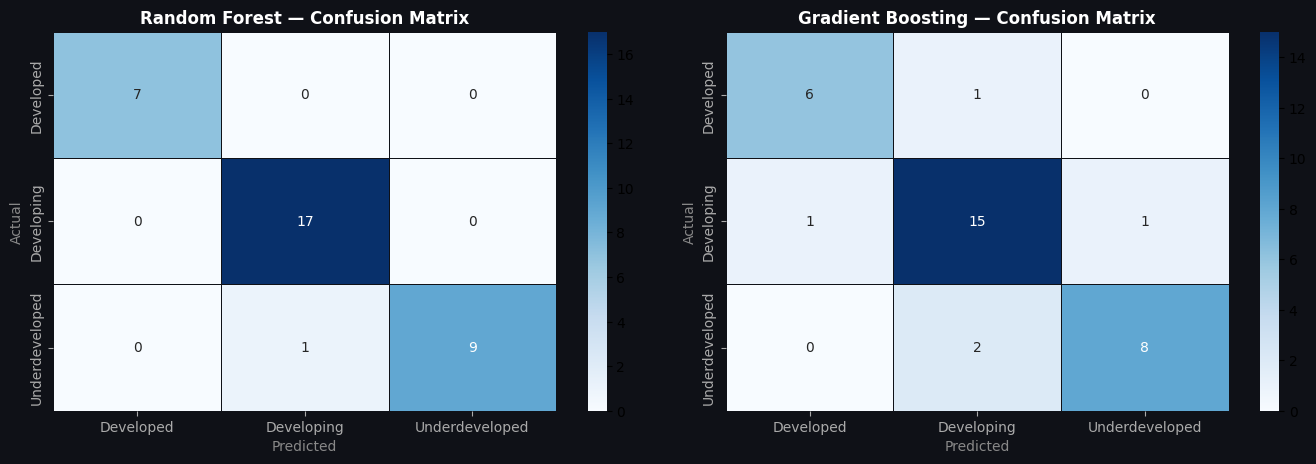

  ✅  Confusion matrices saved: confusion_matrices.png


In [29]:
fig2, axes = plt.subplots(1, 2, figsize=(14, 5))
fig2.patch.set_facecolor('#0F1117')
 
for ax, pred, name in zip(axes, [rf_pred, gbm_pred], ['Random Forest', 'Gradient Boosting']):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_,
                ax=ax, linewidths=0.5, linecolor='#0F1117')
    ax.set_title(f'{name} — Confusion Matrix', color='white', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted', color='#888888')
    ax.set_ylabel('Actual', color='#888888')
    ax.tick_params(colors='#AAAAAA')
    ax.set_facecolor('#1A1D27')
 
fig2.patch.set_facecolor('#0F1117')
plt.tight_layout(pad=2)
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight',
            facecolor='#0F1117')
plt.show()
print("  ✅  Confusion matrices saved: confusion_matrices.png")
 

In [30]:
elapsed = time.time() - START
print(f"\n{'='*65}")
print("  FINAL SUMMARY REPORT")
print(f"{'='*65}")
print(f"\n  Dataset          : {len(df)} countries | {len(FEATURES)} features")
print(f"\n  ── CLUSTERING ──")
print(f"  K-Means (K=3)    : Underdeveloped={sum(df['dev_level']=='Underdeveloped')} | "
      f"Developing={sum(df['dev_level']=='Developing')} | "
      f"Developed={sum(df['dev_level']=='Developed')}")
print(f"  Silhouette (K=3) : {silhouette_score(X_scaled, km_labels):.4f}")
print(f"  DBSCAN           : {n_clusters_db} cluster(s) | {n_noise} outliers")
print(f"\n  ── CLASSIFICATION ──")
print(f"  Random Forest    : CV={rf_cv.mean()*100:.2f}% ± {rf_cv.std()*100:.2f}% | "
      f"Test={rf_acc*100:.2f}%  {'✅' if rf_acc>0.8 else '❌'} (>80% target)")
print(f"  Gradient Boost   : CV={gbm_cv.mean()*100:.2f}% ± {gbm_cv.std()*100:.2f}% | "
      f"Test={gbm_acc*100:.2f}%  {'✅' if gbm_acc>0.8 else '❌'} (>80% target)")
print(f"\n  ── TOP 5 AID PRIORITY COUNTRIES ──")
for _, row in top20.head(5).iterrows():
    print(f"  {row['country']:<30} GDP=${row['gdpp']:6.0f} | "
          f"Child mort={row['child_mort']:5.1f} | Life exp={row['life_expec']:.1f}yr")
print(f"\n  ── PCA VARIANCE ──")
print(f"  PC1={pca2.explained_variance_ratio_[0]*100:.1f}% | "
      f"PC2={pca2.explained_variance_ratio_[1]*100:.1f}% | "
      f"Total={pca2.explained_variance_ratio_.sum()*100:.1f}%")
print(f"\n  ⏱  Total runtime : {elapsed:.1f}s  {'✅' if elapsed<60 else '⚠ >60s'} (<60s target)")
print(f"\n  📁  Outputs saved : customer_intelligence_system.png")
print(f"                      confusion_matrices.png")
print(f"\n{'='*65}")
print("  MISSION RECOMMENDATION:")
print("  Immediate aid to Sub-Saharan Africa + Haiti is critical.")
print("  Countries with child_mort > 100 and GDP/cap < $500 are the")
print("  highest priority targets for HELP International's $10M fund.")
print(f"{'='*65}\n")
 


  FINAL SUMMARY REPORT

  Dataset          : 167 countries | 9 features

  ── CLUSTERING ──
  K-Means (K=3)    : Underdeveloped=47 | Developing=84 | Developed=36
  Silhouette (K=3) : 0.2833
  DBSCAN           : 1 cluster(s) | 15 outliers

  ── CLASSIFICATION ──
  Random Forest    : CV=96.40% ± 4.46% | Test=97.06%  ✅ (>80% target)
  Gradient Boost   : CV=94.60% ± 5.22% | Test=85.29%  ✅ (>80% target)

  ── TOP 5 AID PRIORITY COUNTRIES ──
  Haiti                          GDP=$   662 | Child mort=208.0 | Life exp=32.1yr
  Central African Republic       GDP=$   446 | Child mort=149.0 | Life exp=47.5yr
  Sierra Leone                   GDP=$   399 | Child mort=160.0 | Life exp=55.0yr
  Chad                           GDP=$   897 | Child mort=150.0 | Life exp=56.5yr
  Mali                           GDP=$   708 | Child mort=137.0 | Life exp=59.5yr

  ── PCA VARIANCE ──
  PC1=46.0% | PC2=17.2% | Total=63.1%

  ⏱  Total runtime : 13.2s  ✅ (<60s target)

  📁  Outputs saved : customer_intelligence_